In [1]:
import sys, re, json
sys.path.append('..') 

from scripts.constants import *
from scripts.logging_config import *
from scripts.utils import *
from scripts.sedona_config import *

import pandas as pd
import geopandas as gpd
from tqdm import tqdm

In [11]:
# IN paths
vom_dir = RASTER_IN_DIR / "Defra" / "VOM"
vom_lad_dir = vom_dir / "LADs"
chm_lad_tiles_path = vom_lad_dir / "LAD_CHM_tiles_paths.json"
T3_30_300_DIR = VECTOR_OUT_DIR / "3-30-300"
T3_dir = T3_30_300_DIR / "T3"
# T30_dir = T3_30_300_DIR / "T30"
# T300_dir = T3_30_300_DIR / "T300"
trees_dir = T3_30_300_DIR / "VOM_Trees"
chm_lad_tiles_dict = json.load(open(chm_lad_tiles_path))
imd_lsoa_bua_boundaries_path = VECTOR_OUT_DIR / "IMD" / "English_IMD_2019_BUA_filtered_boundaries.geojson"
# buildings_path = VECTOR_IN_DIR / "EDINA" / "Buildings_6183" / "edition_17_0_new_format.gpkg"
buildings_path = VECTOR_IN_DIR / "EDINA" / "Buildings_6183" / "Buildings_6183.parquet"

In [45]:
def extract_grid_reference(filename: str) -> str|None:
    """
    Extracts a grid reference from a given filename.
    The function searches for a pattern in the filename that matches 'VOM' or 'VOM_HS'
    followed by an underscore, a two-letter code, a four-digit number, and another underscore.
    If such a pattern is found, it returns the grid reference (the two-letter code and the four-digit number).
    If no match is found, it returns None.
    Parameters:
        filename (str | Path): The name of the file from which to extract the grid reference.
    Returns:
        str | None: The extracted grid reference if a match is found, otherwise None.
    """

    match = re.search(r'VOM_([A-Z]{2}\d{4})_', filename)
    if match:
        return match.group(1)
    return None

In [52]:
def check_tree_vom_pair(chm_path: str|Path, trees_dir: str|Path) -> bool:
    """
    Check if a CHM file has a corresponding tree file.
    Parameters:
        chm_path (str | Path): The path to the CHM file.
        trees_dir (str | Path): The directory containing the tree files.
    Returns:
        bool: True if a corresponding tree file exists, otherwise False.
    """

    tile_name = extract_grid_reference(chm_path)
    chm_path = chm_path if isinstance(chm_path, Path) else Path(chm_path)
    year = chm_path.parent.name

    trees_path = trees_dir / f"VOM_trees_{tile_name}_{year}.gpkg"

    if trees_path.exists():
        return str(trees_path)

In [62]:
vom_tree_pair_dict = {geo_code: [(chm_path, check_tree_vom_pair(chm_path, trees_dir)) for chm_path in lst] for geo_code, lst in chm_lad_tiles_dict.items()}

In [72]:
# Convert vom_tree_pair_dict to a DataFrame
vom_tree_pair_df = pd.DataFrame.from_dict(vom_tree_pair_dict, orient='index').stack().reset_index()
vom_tree_pair_df.columns = ['geo_code', 'index', 'pair']
vom_tree_pair_df = vom_tree_pair_df.drop(columns=['index'])
vom_tree_pair_df[['chm_path', 'tree_path']] = pd.DataFrame(vom_tree_pair_df['pair'].tolist(), index=vom_tree_pair_df.index)
vom_tree_pair_df = vom_tree_pair_df.drop(columns=['pair'])
no_tree_file_df = vom_tree_pair_df[vom_tree_pair_df['tree_path'].isnull()]

In [79]:
trees_path_lst = [tree_path for _, tree_path in vom_tree_pair_dict['E06000008'] if tree_path is not None]
trees_path_lst

['/maps/acz25/phd-thesis-data/output/vector/3-30-300/VOM_Trees/VOM_trees_SD6515_2022.gpkg',
 '/maps/acz25/phd-thesis-data/output/vector/3-30-300/VOM_Trees/VOM_trees_SD6015_2022.gpkg',
 '/maps/acz25/phd-thesis-data/output/vector/3-30-300/VOM_Trees/VOM_trees_SD6510_2022.gpkg',
 '/maps/acz25/phd-thesis-data/output/vector/3-30-300/VOM_Trees/VOM_trees_SD6525_2018.gpkg',
 '/maps/acz25/phd-thesis-data/output/vector/3-30-300/VOM_Trees/VOM_trees_SD6025_2018.gpkg',
 '/maps/acz25/phd-thesis-data/output/vector/3-30-300/VOM_Trees/VOM_trees_SD6020_2022.gpkg',
 '/maps/acz25/phd-thesis-data/output/vector/3-30-300/VOM_Trees/VOM_trees_SD6530_2018.gpkg',
 '/maps/acz25/phd-thesis-data/output/vector/3-30-300/VOM_Trees/VOM_trees_SD7515_2019.gpkg',
 '/maps/acz25/phd-thesis-data/output/vector/3-30-300/VOM_Trees/VOM_trees_SD7015_2022.gpkg',
 '/maps/acz25/phd-thesis-data/output/vector/3-30-300/VOM_Trees/VOM_trees_SD7510_2019.gpkg',
 '/maps/acz25/phd-thesis-data/output/vector/3-30-300/VOM_Trees/VOM_trees_SD7010_

In [80]:
trees_gdf_lst = [gpd.read_file(tree_path) for tree_path in trees_path_lst]

In [81]:
merged_trees_gdf = gpd.GeoDataFrame(pd.concat(trees_gdf_lst, ignore_index=True))
merged_trees_gdf

,treeID,height,area,geometry
0,1,7.818024,1.000703,"MULTIPOLYGON (((365846 420000, 365846 419999, ..."
1,2,20.145523,1.000702,"MULTIPOLYGON (((365858 420000, 365858 419999, ..."
2,3,12.865013,1.000704,"MULTIPOLYGON (((365885 420000, 365885 419999, ..."
3,4,5.117996,1.000703,"MULTIPOLYGON (((365892 420000, 365892 419999, ..."
4,5,18.455521,1.000703,"MULTIPOLYGON (((365902 420000, 365902 419999, ..."
...,...,...,...,...
1207374,82172,11.084995,1.000708,"MULTIPOLYGON (((374370 430001, 374370 430000, ..."
1207375,82173,5.544994,1.000708,"MULTIPOLYGON (((374639 430001, 374639 430000, ..."
1207376,82174,6.289993,1.000707,"MULTIPOLYGON (((374897 430001, 374897 430000, ..."
1207377,82175,8.214996,1.000707,"MULTIPOLYGON (((374901 430001, 374901 430000, ..."


In [ ]:
from shapely.ops import unary_union
dissolved_geometry = unary_union(merged_trees_gdf.geometry)

In [86]:
merged_trees_gdf[merged_trees_gdf.area >= 4]

,treeID,height,area,geometry
70,71,20.336014,83.058301,"MULTIPOLYGON (((365859 420000, 365859 419999, ..."
71,72,6.153015,19.013357,"MULTIPOLYGON (((366004 420000, 366004 419997, ..."
72,73,9.876038,44.030941,"MULTIPOLYGON (((366107 420000, 366107 419998, ..."
73,74,8.769012,31.021801,"MULTIPOLYGON (((366126 420000, 366126 419998, ..."
74,75,8.233032,24.016878,"MULTIPOLYGON (((366139 420000, 366139 419998, ..."
...,...,...,...,...
1207328,82126,8.639992,22.015535,"MULTIPOLYGON (((374009 430006, 374009 430005, ..."
1207329,82127,6.069992,25.017677,"MULTIPOLYGON (((374270 430006, 374270 430005, ..."
1207330,82128,13.500000,30.021135,"MULTIPOLYGON (((373622 430003, 373622 430000, ..."
1207331,82129,8.639992,12.008474,"MULTIPOLYGON (((374013 430005, 374013 430002, ..."


<Axes: >

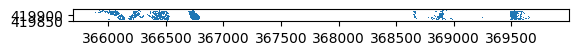

In [84]:
merged_trees_gdf.iloc[1000:2000].plot()

In [9]:
os.environ["JAVA_HOME"] = '/home/acz25/.jdk/jdk8u432-b06'
sedona = get_spark()

24/12/08 21:56:13 WARN UDTRegistration: Cannot register UDT for org.geotools.coverage.grid.GridCoverage2D, which is already registered.
24/12/08 21:56:13 WARN SimpleFunctionRegistry: The function rs_union_aggr replaced a previously registered function.
24/12/08 21:56:13 WARN UDTRegistration: Cannot register UDT for org.locationtech.jts.geom.Geometry, which is already registered.
24/12/08 21:56:13 WARN UDTRegistration: Cannot register UDT for org.locationtech.jts.index.SpatialIndex, which is already registered.
24/12/08 21:56:13 WARN SimpleFunctionRegistry: The function st_envelope_aggr replaced a previously registered function.
24/12/08 21:56:13 WARN SimpleFunctionRegistry: The function st_intersection_aggr replaced a previously registered function.
24/12/08 21:56:13 WARN SimpleFunctionRegistry: The function st_union_aggr replaced a previously registered function.


In [10]:
# buildings_gdf = gpd.read_file(buildings_path, layer='edition_17_0_new_format')
buildings_rdd = sedona.read.format("geoparquet").load(str(buildings_path))
buildings_rdd.printSchema()

root
 |-- building_area: double (nullable = true)
 |-- distance_building: float (nullable = true)
 |-- distance_water: double (nullable = true)
 |-- height: double (nullable = true)
 |-- map_simple_use: string (nullable = true)
 |-- map_use: string (nullable = true)
 |-- premise_floor_count: string (nullable = true)
 |-- premise_type: string (nullable = true)
 |-- premise_use: string (nullable = true)
 |-- premise_year: double (nullable = true)
 |-- verisk_building_id: long (nullable = true)
 |-- verisk_premise_id: long (nullable = true)
 |-- geometry: geometry (nullable = true)

